## **Modelos Deep Learning em PyTorch**

**Tarefa 3 do Trabalho Prático — Aprendizagem Profunda**

1. **DNNs** — Feedforward com features tabulares, variando largura
2. **Embedding + DNN** — Embedding treinável, variando dimensão do embedding
3. **BiLSTM** — LSTM bidirecional, variando dimensão do hidden state
4. **BiGRU** — Alternativa ao LSTM (comparação LSTM vs GRU)
5. **BiLSTM + GloVe** — Embeddings pré-treinados, frozen vs fine-tuned
6. **Stratified K-Fold (K=5)** — Comparação robusta
7. **Retreino e avaliação final** no dataset do professor

### **1. Imports e Configuração**

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os, time, re
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report

sys.path.append(os.path.abspath('../src'))
from utils import (prepare_text_data, prepare_fold_data, transform_new_texts,
                    clean_text, stratified_k_fold)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

Dispositivo: cuda


### **2. Carregamento dos Dados**

In [12]:
print('A carregar os datasets...')

df_main = pd.read_csv('../data/dataset.csv', sep=';')
df_main.columns = df_main.columns.str.lower()
textos = df_main['text'].tolist()
labels = df_main['label'].tolist()

df_test = pd.read_csv('../data/raw/dataset-exemplos.csv', sep=';')
df_test.columns = df_test.columns.str.lower()
textos_test = df_test['text'].tolist()
labels_test = df_test['label'].tolist()

class_names_list = sorted(set(labels))
num_classes = len(class_names_list)

print(f'  Dataset principal: {len(textos)} textos')
print(f'  Dataset teste (prof): {len(textos_test)} textos')
print(f'  Classes: {class_names_list}')

A carregar os datasets...
  Dataset principal: 5000 textos
  Dataset teste (prof): 125 textos
  Classes: ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']


### **3. Definição dos Modelos**

Cada família tem duas variantes, explorando o hiperparâmetro mais relevante:

| Família | Variantes | Hiperparâmetro explorado |
|---------|-----------|--------------------------|
| **DNN (tabular)** | Wide (256→64), Narrow (128→32) | Largura da rede |
| **Embedding + DNN** | embed 64d, embed 128d | Dimensão do embedding |
| **BiLSTM** | hidden 64, hidden 128 | Dimensão do hidden state |
| **BiGRU** | hidden 64, hidden 128 | LSTM vs GRU + hidden size |
| **BiLSTM + GloVe** | frozen, fine-tuned | Congelar vs ajustar embeddings |

Todos os modelos sequenciais usam o mesmo classificador (128→64→classes) para comparação justa.

In [13]:
# ══════════════════════════════════════
# DNNs tabulares
# ══════════════════════════════════════

class DNNWide(nn.Module):
    """256 → 128 → classes"""
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, num_classes))
    def forward(self, x): return self.net(x)

class DNNNarrow(nn.Module):
    """128 → 64 → classes"""
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, num_classes))
    def forward(self, x): return self.net(x)

# ══════════════════════════════════════
# Embedding + DNN — varia dimensão do embedding
# Classificador fixo: 128 → 64 → classes
# ══════════════════════════════════════

class EmbeddingDNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.net = nn.Sequential(
            nn.Linear(embed_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, num_classes))
    def forward(self, x):
        embedded = self.embedding(x)
        mask = (x != 0).unsqueeze(-1).float()
        pooled = (embedded * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        return self.net(pooled)

# ══════════════════════════════════════
# BiLSTM — varia hidden_dim
# ══════════════════════════════════════

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        combined = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.fc(self.dropout(combined))

# ══════════════════════════════════════
# BiGRU — alternativa ao LSTM, varia hidden_dim
# ══════════════════════════════════════

class BiGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, bidirectional=True,
                          dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, hidden = self.gru(embedded)
        combined = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.fc(self.dropout(combined))

# ══════════════════════════════════════
# BiLSTM + GloVe — varia frozen vs fine-tuned
# ══════════════════════════════════════

class BiLSTMGloVe(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_classes,
                 num_layers=2, dropout=0.3, freeze_embed=True):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.freeze_embed = freeze_embed
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=freeze_embed, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, num_classes))
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        combined = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.fc(self.dropout(combined))

print('Modelos definidos.')

Modelos definidos.


### **4. Validação Cruzada — Stratified K-Fold (K=5)**

Para cada fold, TF-IDF e vocabulários são ajustados apenas no treino.

In [14]:
K = 5
FEAT_PARAMS = dict(max_features=1500, char_features=1500, ngram_range=(1, 2), stop_words=set())
EMBED_DIM_DEFAULT = 64
HIDDEN_DIM_DEFAULT = 64
MAX_SEQ_LEN = 150
VOCAB_SIZE = 10000
GLOVE_DIM = 100
GLOVE_HIDDEN = 128

def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return [t for t in text.split() if len(t) > 1]

def texts_to_sequences(texts, word2idx, max_len):
    seqs = []
    for text in texts:
        tokens = simple_tokenize(text)
        seq = [word2idx.get(t, 1) for t in tokens[:max_len]]
        seqs.append(seq + [0] * (max_len - len(seq)))
    return np.array(seqs)

def build_fold_vocab(texts_tr):
    wc = Counter()
    for t in texts_tr: wc.update(simple_tokenize(t))
    mc = wc.most_common(VOCAB_SIZE - 2)
    w2i = {w: i+2 for i, (w, _) in enumerate(mc)}
    w2i['<PAD>'] = 0; w2i['<UNK>'] = 1
    return w2i

def train_pytorch(model, X_tr, y_tr, X_vl, y_vl,
                  epochs=100, lr=0.001, wd=1e-3, patience=10, bs=128):
    model = model.to(device)
    crit = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=0.5, patience=5)
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=bs, shuffle=True)
    best_vl = float('inf'); wait = 0; best_st = None
    for ep in range(epochs):
        model.train()
        for bx, by in loader:
            opt.zero_grad(); crit(model(bx), by).backward(); opt.step()
        model.eval()
        with torch.no_grad(): vl = crit(model(X_vl), y_vl).item()
        sched.step(vl)
        if vl < best_vl:
            best_vl = vl; wait = 0
            best_st = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    if best_st: model.load_state_dict(best_st)
    model.eval()
    with torch.no_grad():
        return (torch.argmax(model(X_vl), 1) == y_vl).float().mean().item()

# Helper para correr K-Fold sequencial
def kfold_seq(nome, model_fn):
    print(f'\n{nome}:')
    accs = []
    for fold, (tr_i, vl_i) in enumerate(stratified_k_fold(labels, K)):
        t_tr = [textos[i] for i in tr_i]; t_vl = [textos[i] for i in vl_i]
        l_tr = [labels[i] for i in tr_i]; l_vl = [labels[i] for i in vl_i]
        w2i = build_fold_vocab(t_tr); vs = len(w2i)
        s_tr = texts_to_sequences(t_tr, w2i, MAX_SEQ_LEN)
        s_vl = texts_to_sequences(t_vl, w2i, MAX_SEQ_LEN)
        y_tr = np.array([class_names_list.index(l) for l in l_tr])
        y_vl = np.array([class_names_list.index(l) for l in l_vl])
        torch.manual_seed(42)
        acc = train_pytorch(
            model_fn(vs, num_classes),
            torch.LongTensor(s_tr).to(device), torch.LongTensor(y_tr).to(device),
            torch.LongTensor(s_vl).to(device), torch.LongTensor(y_vl).to(device),
            wd=1e-4, patience=10)
        accs.append(acc); print(f'  Fold {fold+1}: {acc:.2%}')
    cv_results[nome] = np.array(accs)
    print(f'  → {np.mean(accs):.2%} ± {np.std(accs):.2%}')

print('Funções definidas.')

Funções definidas.


In [15]:
import zipfile, urllib.request
GLOVE_DIR = '../data/glove'
GLOVE_PATH = os.path.join(GLOVE_DIR, f'glove.6B.{GLOVE_DIM}d.txt')
if not os.path.exists(GLOVE_PATH):
    os.makedirs(GLOVE_DIR, exist_ok=True)
    zip_path = os.path.join(GLOVE_DIR, 'glove.6B.zip')
    if not os.path.exists(zip_path):
        print('A descarregar GloVe 6B (822MB)...')
        urllib.request.urlretrieve('https://nlp.stanford.edu/data/glove.6B.zip', zip_path)
    print('A extrair...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extract(f'glove.6B.{GLOVE_DIM}d.txt', GLOVE_DIR)
else:
    print(f'GloVe já disponível em {GLOVE_PATH}')
print(f'A carregar GloVe {GLOVE_DIM}d...')
glove_all = {}
with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        glove_all[parts[0]] = np.array(parts[1:], dtype=np.float32)
print(f'✅ GloVe: {len(glove_all)} vetores')

def build_emb_matrix(w2i, glove, dim):
    mat = np.random.normal(scale=0.6, size=(len(w2i), dim))
    mat[0] = 0; found = 0
    for w, i in w2i.items():
        if w in glove: mat[i] = glove[w]; found += 1
    return mat, found

GloVe já disponível em ../data/glove\glove.6B.100d.txt
A carregar GloVe 100d...
✅ GloVe: 400000 vetores


In [16]:
print("=" * 60)
print("Stratified 5-Fold Cross-Validation")
print("=" * 60)
cv_results = {}

# ═══ A) DNNs tabulares — largura ═══
tab_cfgs = {
    'DNN Wide (256→128)': lambda i, n: DNNWide(i, n),
    'DNN Narrow (128→64)': lambda i, n: DNNNarrow(i, n),
}
for nome, fn in tab_cfgs.items():
    print(f'\n{nome}:')
    accs = []
    for fold, (tr_i, vl_i) in enumerate(stratified_k_fold(labels, K)):
        t_tr = [textos[i] for i in tr_i]; t_vl = [textos[i] for i in vl_i]
        l_tr = [labels[i] for i in tr_i]; l_vl = [labels[i] for i in vl_i]
        X_tr, _, X_vl, _, _, _ = prepare_fold_data(t_tr, l_tr, t_vl, l_vl, **FEAT_PARAMS)
        y_tr = np.array([class_names_list.index(l) for l in l_tr])
        y_vl = np.array([class_names_list.index(l) for l in l_vl])
        torch.manual_seed(42)
        acc = train_pytorch(fn(X_tr.shape[1], num_classes),
            torch.FloatTensor(X_tr).to(device), torch.LongTensor(y_tr).to(device),
            torch.FloatTensor(X_vl).to(device), torch.LongTensor(y_vl).to(device))
        accs.append(acc); print(f'  Fold {fold+1}: {acc:.2%}')
    cv_results[nome] = np.array(accs)
    print(f'  → {np.mean(accs):.2%} ± {np.std(accs):.2%}')

# ═══ B) Embedding+DNN — dimensão do embedding (64 vs 128) ═══
kfold_seq('Embed+DNN (64d)',  lambda vs, nc: EmbeddingDNN(vs, 64, nc))
kfold_seq('Embed+DNN (128d)', lambda vs, nc: EmbeddingDNN(vs, 128, nc))

# ═══ C) BiLSTM — dimensão do hidden state (64 vs 128) ═══
kfold_seq('BiLSTM (h=64)',  lambda vs, nc: BiLSTM(vs, 64, 64, nc))
kfold_seq('BiLSTM (h=128)', lambda vs, nc: BiLSTM(vs, 64, 128, nc))

# ═══ D) BiGRU — LSTM vs GRU + hidden size ═══
kfold_seq('BiGRU (h=64)',  lambda vs, nc: BiGRU(vs, 64, 64, nc))
kfold_seq('BiGRU (h=128)', lambda vs, nc: BiGRU(vs, 64, 128, nc))

# ═══ E) BiLSTM+GloVe — frozen vs fine-tuned ═══
for nome, freeze in [('BiLSTM+GloVe (frozen)', True), ('BiLSTM+GloVe (fine-tuned)', False)]:
    print(f'\n{nome}:')
    accs = []
    for fold, (tr_i, vl_i) in enumerate(stratified_k_fold(labels, K)):
        t_tr = [textos[i] for i in tr_i]; t_vl = [textos[i] for i in vl_i]
        l_tr = [labels[i] for i in tr_i]; l_vl = [labels[i] for i in vl_i]
        w2i = build_fold_vocab(t_tr)
        emb, found = build_emb_matrix(w2i, glove_all, GLOVE_DIM)
        if fold == 0: print(f'    GloVe: {found}/{len(w2i)-2}')
        s_tr = texts_to_sequences(t_tr, w2i, MAX_SEQ_LEN)
        s_vl = texts_to_sequences(t_vl, w2i, MAX_SEQ_LEN)
        y_tr = np.array([class_names_list.index(l) for l in l_tr])
        y_vl = np.array([class_names_list.index(l) for l in l_vl])
        torch.manual_seed(42)
        acc = train_pytorch(
            BiLSTMGloVe(emb, GLOVE_HIDDEN, num_classes, freeze_embed=freeze),
            torch.LongTensor(s_tr).to(device), torch.LongTensor(y_tr).to(device),
            torch.LongTensor(s_vl).to(device), torch.LongTensor(y_vl).to(device),
            wd=1e-4, patience=15)
        accs.append(acc); print(f'  Fold {fold+1}: {acc:.2%}')
    cv_results[nome] = np.array(accs)
    print(f'  → {np.mean(accs):.2%} ± {np.std(accs):.2%}')

Stratified 5-Fold Cross-Validation

DNN Wide (256→128):
  Fold 1: 84.70%
  Fold 2: 83.10%
  Fold 3: 85.60%
  Fold 4: 84.90%
  Fold 5: 85.40%
  → 84.74% ± 0.88%

DNN Narrow (128→64):
  Fold 1: 83.60%
  Fold 2: 83.40%
  Fold 3: 85.70%
  Fold 4: 85.40%
  Fold 5: 84.90%
  → 84.60% ± 0.94%

Embed+DNN (64d):
  Fold 1: 70.40%
  Fold 2: 69.70%
  Fold 3: 67.90%
  Fold 4: 71.50%
  Fold 5: 68.80%
  → 69.66% ± 1.25%

Embed+DNN (128d):
  Fold 1: 67.30%
  Fold 2: 68.30%
  Fold 3: 70.70%
  Fold 4: 70.80%
  Fold 5: 68.60%
  → 69.14% ± 1.38%

BiLSTM (h=64):
  Fold 1: 65.20%
  Fold 2: 59.50%
  Fold 3: 63.60%
  Fold 4: 61.00%
  Fold 5: 51.90%
  → 60.24% ± 4.62%

BiLSTM (h=128):
  Fold 1: 58.90%
  Fold 2: 54.80%
  Fold 3: 60.30%
  Fold 4: 65.60%
  Fold 5: 49.10%
  → 57.74% ± 5.53%

BiGRU (h=64):
  Fold 1: 64.40%
  Fold 2: 64.90%
  Fold 3: 74.00%
  Fold 4: 60.70%
  Fold 5: 67.10%
  → 66.22% ± 4.40%

BiGRU (h=128):
  Fold 1: 64.70%
  Fold 2: 68.20%
  Fold 3: 68.60%
  Fold 4: 65.20%
  Fold 5: 65.10%
  → 66.3

In [17]:
rows = []
for nome, accs in cv_results.items():
    rows.append({'Modelo': nome, 'Média': f'{accs.mean():.2%}',
                 'Std': f'±{accs.std():.2%}', 'Min': f'{accs.min():.2%}', 'Max': f'{accs.max():.2%}'})
df_cv = pd.DataFrame(rows).sort_values('Média', ascending=False)
print('\n' + '=' * 60)
print('RESUMO K-FOLD CV')
print('=' * 60)
print(df_cv.to_string(index=False))


RESUMO K-FOLD CV
                   Modelo  Média    Std    Min    Max
       DNN Wide (256→128) 84.74% ±0.88% 83.10% 85.60%
      DNN Narrow (128→64) 84.60% ±0.94% 83.40% 85.70%
    BiLSTM+GloVe (frozen) 72.10% ±2.80% 67.90% 75.10%
          Embed+DNN (64d) 69.66% ±1.25% 67.90% 71.50%
         Embed+DNN (128d) 69.14% ±1.38% 67.30% 70.80%
            BiGRU (h=128) 66.36% ±1.68% 64.70% 68.60%
             BiGRU (h=64) 66.22% ±4.40% 60.70% 74.00%
BiLSTM+GloVe (fine-tuned) 62.26% ±1.94% 59.20% 65.10%
            BiLSTM (h=64) 60.24% ±4.62% 51.90% 65.20%
           BiLSTM (h=128) 57.74% ±5.53% 49.10% 65.60%


### **5. Retreino do Melhor Modelo + Avaliação no Teste**

In [18]:
X_train, Y_train_oh, X_val, Y_val_oh, transformers, encoder = prepare_text_data(
    textos, labels, max_features=1500, char_features=1500, val_size=0.20,
    use_stratify=True, ngram_range=(1, 2), stop_words=set())
X_test = transform_new_texts(textos_test, transformers)
Y_test_oh = encoder.transform(np.array(labels_test))
y_train = np.argmax(Y_train_oh, axis=1); y_val = np.argmax(Y_val_oh, axis=1)
y_test = np.argmax(Y_test_oh, axis=1)
class_names = encoder.classes; input_size = X_train.shape[1]

melhor_nome = df_cv.iloc[0]['Modelo']
print(f'Melhor modelo: {melhor_nome}')

tab_map = {'DNN Wide (256→128)': DNNWide, 'DNN Narrow (128→64)': DNNNarrow}

if melhor_nome in tab_map:
    X_tr_t = torch.FloatTensor(X_train).to(device); y_tr_t = torch.LongTensor(y_train).to(device)
    X_vl_t = torch.FloatTensor(X_val).to(device); y_vl_t = torch.LongTensor(y_val).to(device)
    X_te_t = torch.FloatTensor(X_test).to(device); y_te_t = torch.LongTensor(y_test).to(device)
    torch.manual_seed(42)
    melhor_model = tab_map[melhor_nome](input_size, num_classes).to(device)
    t0 = time.time()
    train_pytorch(melhor_model, X_tr_t, y_tr_t, X_vl_t, y_vl_t, patience=10)
    tempo = time.time() - t0
    melhor_model.eval()
    with torch.no_grad():
        train_acc = (torch.argmax(melhor_model(X_tr_t), 1) == y_tr_t).float().mean().item()
        val_acc = (torch.argmax(melhor_model(X_vl_t), 1) == y_vl_t).float().mean().item()
        test_acc = (torch.argmax(melhor_model(X_te_t), 1) == y_te_t).float().mean().item()
    test_input = X_te_t; test_labels = y_te_t; is_tabular = True

else:
    from utils import train_test_split
    t_tr, t_vl, l_tr, l_vl = train_test_split(textos, labels, test_size=0.20, random_state=42, stratify=labels)
    word2idx = build_fold_vocab(t_tr); actual_vocab_size = len(word2idx)
    s_tr = texts_to_sequences(t_tr, word2idx, MAX_SEQ_LEN)
    s_vl = texts_to_sequences(t_vl, word2idx, MAX_SEQ_LEN)
    s_te = texts_to_sequences(textos_test, word2idx, MAX_SEQ_LEN)
    y_tr_s = np.array([list(class_names).index(l) for l in l_tr])
    y_vl_s = np.array([list(class_names).index(l) for l in l_vl])
    y_te_s = np.array([list(class_names).index(l) for l in labels_test])

    torch.manual_seed(42)
    seq_map = {
        'Embed+DNN (64d)':  lambda: EmbeddingDNN(actual_vocab_size, 64, num_classes),
        'Embed+DNN (128d)': lambda: EmbeddingDNN(actual_vocab_size, 128, num_classes),
        'BiLSTM (h=64)':  lambda: BiLSTM(actual_vocab_size, 64, 64, num_classes),
        'BiLSTM (h=128)': lambda: BiLSTM(actual_vocab_size, 64, 128, num_classes),
        'BiGRU (h=64)':   lambda: BiGRU(actual_vocab_size, 64, 64, num_classes),
        'BiGRU (h=128)':  lambda: BiGRU(actual_vocab_size, 64, 128, num_classes),
    }
    glove_map = {'BiLSTM+GloVe (frozen)': True, 'BiLSTM+GloVe (fine-tuned)': False}

    if melhor_nome in seq_map:
        melhor_model = seq_map[melhor_nome]()
    elif melhor_nome in glove_map:
        emb, _ = build_emb_matrix(word2idx, glove_all, GLOVE_DIM)
        melhor_model = BiLSTMGloVe(emb, GLOVE_HIDDEN, num_classes, freeze_embed=glove_map[melhor_nome])
    else:
        raise ValueError(f'Modelo desconhecido: {melhor_nome}')

    t0 = time.time()
    train_pytorch(melhor_model,
        torch.LongTensor(s_tr).to(device), torch.LongTensor(y_tr_s).to(device),
        torch.LongTensor(s_vl).to(device), torch.LongTensor(y_vl_s).to(device),
        wd=1e-4, patience=15)
    tempo = time.time() - t0
    melhor_model.eval()
    te_t = torch.LongTensor(s_te).to(device); yte_t = torch.LongTensor(y_te_s).to(device)
    with torch.no_grad():
        train_acc = (torch.argmax(melhor_model(torch.LongTensor(s_tr).to(device)), 1) == torch.LongTensor(y_tr_s).to(device)).float().mean().item()
        val_acc = (torch.argmax(melhor_model(torch.LongTensor(s_vl).to(device)), 1) == torch.LongTensor(y_vl_s).to(device)).float().mean().item()
        test_acc = (torch.argmax(melhor_model(te_t), 1) == yte_t).float().mean().item()
    test_input = te_t; test_labels = yte_t; is_tabular = False

print(f'\n🏆 {melhor_nome}: Train {train_acc:.2%} | Val {val_acc:.2%} | Test {test_acc:.2%} | {tempo:.1f}s')

Melhor modelo: DNN Wide (256→128)

🏆 DNN Wide (256→128): Train 98.65% | Val 84.40% | Test 58.40% | 1.2s


### **6. Avaliação Final**

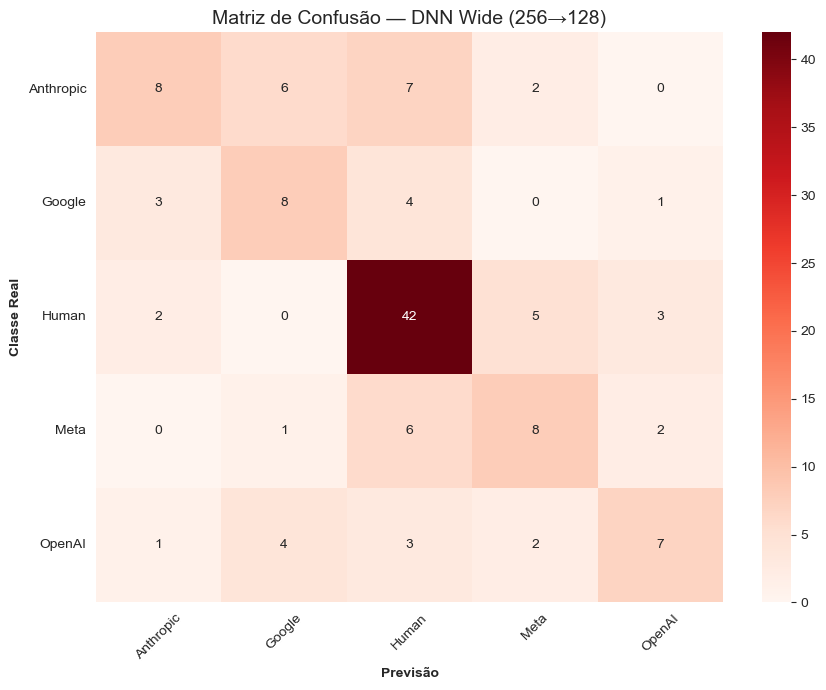


Classification Report — DNN Wide (256→128):
              precision    recall  f1-score   support

   Anthropic       0.57      0.35      0.43        23
      Google       0.42      0.50      0.46        16
       Human       0.68      0.81      0.74        52
        Meta       0.47      0.47      0.47        17
      OpenAI       0.54      0.41      0.47        17

    accuracy                           0.58       125
   macro avg       0.54      0.51      0.51       125
weighted avg       0.58      0.58      0.57       125



In [19]:
melhor_model.eval()
with torch.no_grad(): _, predicted = torch.max(melhor_model(test_input), 1)
y_true = test_labels.cpu().numpy(); y_pred = predicted.cpu().numpy()
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsão', fontweight='bold'); plt.ylabel('Classe Real', fontweight='bold')
plt.title(f'Matriz de Confusão — {melhor_nome}', fontsize=14)
plt.xticks(rotation=45); plt.yticks(rotation=0); plt.tight_layout(); plt.show()
print(f'\nClassification Report — {melhor_nome}:')
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

### **7. Guardar o Modelo**

In [20]:
import pickle
os.makedirs('../models', exist_ok=True)
torch.save(melhor_model.state_dict(), '../models/pytorch.pth')
meta = {'model_class': melhor_model.__class__.__name__, 'input_size': input_size,
        'num_classes': num_classes, 'class_names': list(class_names),
        'transformers': transformers, 'encoder': encoder}
if not is_tabular:
    meta['word2idx'] = word2idx; meta['max_seq_len'] = MAX_SEQ_LEN
    meta['vocab_size'] = actual_vocab_size
    if 'GloVe' in melhor_nome:
        meta['embed_dim'] = GLOVE_DIM; meta['hidden_dim'] = GLOVE_HIDDEN
        meta['embedding_matrix'] = emb; meta['freeze_embed'] = glove_map[melhor_nome]
    elif 'Embed' in melhor_nome:
        meta['embed_dim'] = 128 if '128' in melhor_nome else 64
    else:
        meta['embed_dim'] = 64
        meta['hidden_dim'] = 128 if '128' in melhor_nome else 64
with open('../models/pytorch.pkl', 'wb') as f: pickle.dump(meta, f)
print(f'✅ Modelo guardado: {meta["model_class"]}')

✅ Modelo guardado: DNNWide
